In [1]:
import torch
vers = torch.__version__
print("Torch vers: ", vers)

# PyG installation
!pip install -q torch-scatter -f https://pytorch-geometric.com/whl/torch-${TORCH}+${CUDA}.html
!pip install -q torch-sparse -f https://pytorch-geometric.com/whl/torch-${TORCH}+${CUDA}.html
!pip install -q git+https://github.com/rusty1s/pytorch_geometric.git

import torch_geometric

Torch vers:  2.10.0+cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import pandas as pd
import networkx as nx
import torch.nn.functional as F
import numpy as np

from sklearn.model_selection import train_test_split

from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

In [3]:
from torch_geometric.datasets import UPFD
dataset = UPFD(root=".", name="politifact", feature="bert")
train_idx, test_idx = train_test_split(
    list(range(len(dataset))),
    test_size=0.2,
    random_state=42,
    stratify=[int(d.y.item()) for d in dataset]
)

train_data = dataset[train_idx]
test_data = dataset[test_idx]
print("Train Samples: ", len(train_data))
print("Test Samples: ", len(test_data))

Extracting ./politifact/raw/data.zip
Processing...


Train Samples:  49
Test Samples:  13


Done!


In [4]:
sampleId=1
train_data[sampleId].edge_index

tensor([[ 0,  0,  1,  1,  1,  1,  1,  1,  2,  2,  5,  5,  8, 11, 12, 15],
        [ 1,  2,  3,  4,  5,  6,  7,  8, 14, 15,  9, 10, 11, 12, 13, 16]])

In [5]:
def pyg_graph_to_tables(data, graph_id=0):
    node_df = pd.DataFrame(data.x.numpy())
    node_df["node_id"] = range(data.num_nodes)
    node_df["graph_id"] = graph_id

    edge_df = pd.DataFrame(data.edge_index.T.numpy(), columns=["source", "target"])
    edge_df["graph_id"] = graph_id
    edge_df["edge_type"] = "retweet"

    graph_df = pd.DataFrame({
        "graph_id": [graph_id],
        "label_fake_news": [int(data.y.item())],
        "num_users": [data.num_nodes],
        "num_retweet_edges": [data.edge_index.size(1)]
    })

    return node_df, edge_df, graph_df


node_df, edge_df, graph_df = pyg_graph_to_tables(train_data[0])

print(node_df.head())
print(edge_df.head())
print(graph_df)

          0         1         2         3         4         5         6  \
0 -0.091104  0.032886 -0.074199 -0.129783  0.230473 -0.062967  0.052296   
1  0.007672  0.097180  0.011792  0.147023  0.056175 -0.581662  0.154536   
2  0.019131  0.082428  0.037927  0.184676  0.030546 -0.516407  0.165034   
3  0.019131  0.082428  0.037927  0.184676  0.030546 -0.516407  0.165034   
4  0.019131  0.082428  0.037927  0.184676  0.030546 -0.516407  0.165034   

          7         8         9  ...       760       761       762       763  \
0  0.119553 -0.089390 -0.190301  ... -0.485267 -0.406365  0.056833 -0.208682   
1  0.150511 -0.093894 -0.100805  ... -0.458339 -0.316028  0.020489 -0.345506   
2  0.150417 -0.119881 -0.067527  ... -0.401692 -0.279027  0.016062 -0.271968   
3  0.150417 -0.119881 -0.067527  ... -0.401692 -0.279027  0.016062 -0.271968   
4  0.150417 -0.119881 -0.067527  ... -0.401692 -0.279027  0.016062 -0.271968   

        764       765       766       767  node_id  graph_id  
0 -0.

In [6]:
def build_networkx_graph(data):
    G = nx.DiGraph()

    for node_id in range(data.num_nodes):
        G.add_node(
            node_id,
            embedding=data.x[node_id].numpy()
        )

    edges = data.edge_index.T.tolist()
    G.add_edges_from(edges, edge_type="retweet")

    G.graph["label_fake_news"] = int(data.y.item())

    return G


G = build_networkx_graph(train_data[0])

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Fake news label:", G.graph["label_fake_news"])

Nodes: 71
Edges: 70
Fake news label: 1


In [7]:
from torch_geometric.loader import DataLoader
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

In [8]:
from torch_geometric.nn import global_max_pool as gmp
from torch_geometric.nn import GATConv
from torch.nn import Linear


class GCNFakeNewsClassifier(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes=2):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.classifier = torch.nn.Linear(hidden_channels, 2)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()

        x = global_mean_pool(x, batch)

        return self.classifier(x)

In [9]:
from sklearn.metrics import accuracy_score, f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCNFakeNewsClassifier(train_data.num_features, 64, 1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=0.01)

def train_gnn():
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = batch.to(device)

        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = F.cross_entropy(out, batch.y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [10]:
def evaluate_gnn(loader):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            pred = out.argmax(dim=1)

            preds.extend(pred.cpu().numpy())
            labels.extend(batch.y.cpu().numpy())

    return accuracy_score(labels, preds), classification_report(labels, preds)


for epoch in range(1, 15):
    loss = train_gnn()
    print(f"Epoch {epoch:02d} | Loss: {loss:.4f}")

gnn_acc, gnn_report = evaluate_gnn(test_loader)

print("GNN accuracy:", gnn_acc)
print(gnn_report)

Epoch 01 | Loss: 0.6680
Epoch 02 | Loss: 0.7567
Epoch 03 | Loss: 0.5306
Epoch 04 | Loss: 0.5698
Epoch 05 | Loss: 0.4321
Epoch 06 | Loss: 0.4275
Epoch 07 | Loss: 0.4022
Epoch 08 | Loss: 0.2261
Epoch 09 | Loss: 0.2999
Epoch 10 | Loss: 0.2418
Epoch 11 | Loss: 0.1429
Epoch 12 | Loss: 0.1315
Epoch 13 | Loss: 0.1569
Epoch 14 | Loss: 0.0978
GNN accuracy: 0.9230769230769231
              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.83      1.00      0.91         5

    accuracy                           0.92        13
   macro avg       0.92      0.94      0.92        13
weighted avg       0.94      0.92      0.92        13



In [11]:
def graph_to_vector(data):
    graph_embedding = data.x.mean(dim=0)
    label = int(data.y.item())
    return graph_embedding.numpy(), label


def dataset_to_ml_arrays(dataset):
    X, y = [], []

    for data in dataset:
        graph_vec, label = graph_to_vector(data)
        X.append(graph_vec)
        y.append(label)

    return np.vstack(X), np.array(y)


X_train, y_train = dataset_to_ml_arrays(train_data)
X_test, y_test = dataset_to_ml_arrays(test_data)

In [12]:
lr_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy:
0.7692307692307693
              precision    recall  f1-score   support

           0       0.86      0.75      0.80         8
           1       0.67      0.80      0.73         5

    accuracy                           0.77        13
   macro avg       0.76      0.78      0.76        13
weighted avg       0.78      0.77      0.77        13



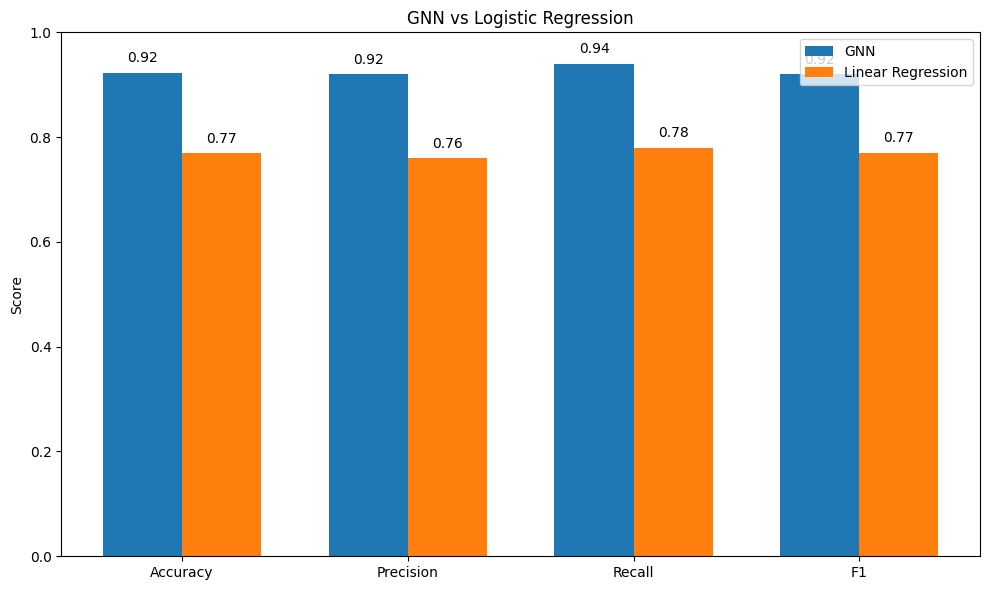

In [13]:
import matplotlib.pyplot as plt
metrics = ["Accuracy", "Precision", "Recall", "F1"]

gnn_scores = [0.9230, 0.92, 0.94, 0.92]
lr_scores = [0.7692, 0.76, 0.78, 0.77]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, gnn_scores, width, label="GNN")
plt.bar(x + width/2, lr_scores, width, label="Linear Regression")

plt.xticks(x, metrics)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("GNN vs Logistic Regression")
plt.legend()

for i, score in enumerate(gnn_scores):
    plt.text(i - width/2, score + 0.02, f"{score:.2f}", ha="center")

for i, score in enumerate(lr_scores):
    plt.text(i + width/2, score + 0.02, f"{score:.2f}", ha="center")

plt.tight_layout()
plt.show()